In [23]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
sp500_px = pd.read_csv('data/sp500_data.csv.gz')
sp500_px.set_index("Unnamed: 0", inplace=True)
sp500_px

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1993-01-29,0.000000,0.060124,-0.022100,0.000000,0.000000,0.018897,0.007368,0.092165,0.259140,-0.007105,...,0.000000,0.000000,0.347160,0.000000,0.041670,0.000000,0.015564,1.750000,0.125000,0.000000
1993-02-01,0.000000,-0.180389,0.027621,0.000000,0.000000,0.018889,0.018425,0.115207,-0.100775,0.063893,...,0.000000,0.000000,-0.231440,0.000000,0.000000,-0.010410,0.007782,1.250000,0.125000,0.000000
1993-02-02,0.000000,-0.120257,0.035900,0.000000,0.000000,-0.075573,0.029482,-0.023041,0.028796,-0.014192,...,0.000000,0.000000,-0.115720,0.000000,0.000000,0.000000,-0.007792,-0.250000,0.000000,0.000000
1993-02-03,0.000000,0.060124,-0.024857,0.000000,0.000000,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,...,0.000000,0.000000,-0.086790,0.000000,0.041670,-0.041670,-0.038919,-0.500000,0.062500,0.000000
1993-02-04,0.000000,-0.360770,-0.060757,0.000000,0.000000,0.113350,-0.022114,0.069862,0.000000,-0.007096,...,0.000000,0.000000,0.144650,0.000000,-0.041660,-0.031260,-0.046711,0.000000,0.062500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,0.019989,-0.529999,-0.379997,0.080002,0.350003,-0.580002,-0.457999,-1.720001,-0.009936,0.039997,...,-2.500000,1.889999,-2.060012,0.150002,-1.630004,-0.990005,-2.250000,1.270019,-1.919998,-0.080002
2015-06-26,-1.299988,-0.330000,-0.390004,-1.820000,0.190003,0.330002,-0.328565,-0.769989,0.020000,0.000000,...,-0.070007,-2.380005,-1.390000,0.550004,-3.509979,-1.080002,-0.800003,-1.900024,-3.629997,0.440002
2015-06-29,-10.299988,-0.410000,-0.670002,-1.250000,-1.919998,-0.510002,-0.139999,-0.949997,-0.100000,-0.040001,...,-2.250000,-5.490005,-5.029999,0.090000,-8.290009,-1.209999,-2.419998,-9.620026,-3.770004,-2.479996


In [34]:
oil_px = sp500_px[['XOM', 'CVX']]
oil_px

,XOM,CVX
Unnamed: 0,,
1993-01-29,-0.016991,0.072921
1993-02-01,0.016991,0.102089
1993-02-02,0.084954,0.029168
1993-02-03,0.067964,0.058337
1993-02-04,0.034378,0.044272
...,...,...
2015-06-25,-0.919998,-1.110001
2015-06-26,0.029999,0.360000
2015-06-29,-0.230003,-0.809998


In [35]:
pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
loadings

,XOM,CVX
0,0.664711,0.747101
1,0.747101,-0.664711


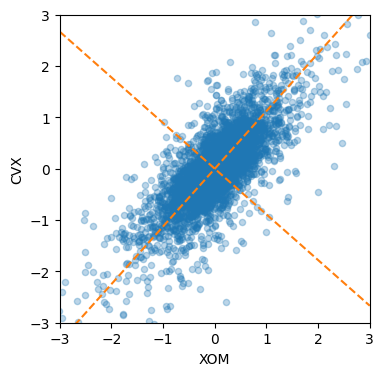

In [36]:
def abline(slope, intercept, ax):
 """Calculate coordinates of a line based on slope and intercept"""
 x_vals = np.array(ax.get_xlim())
 return (x_vals, intercept + slope * x_vals)
ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax),
 '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax),
 '--', color='C1')

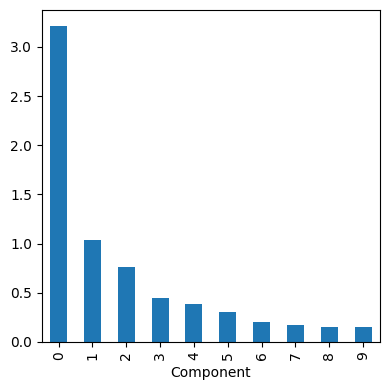

In [42]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
        'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])



top_sp = sp500_px.loc[pd.to_datetime(sp500_px.index) >= '2011-01-01', syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

plt.tight_layout()
plt.show()

In [38]:
sp500_px.columns

Index(['ADS', 'CA', 'MSFT', 'RHT', 'CTSH', 'CSC', 'EMC', 'IBM', 'XRX', 'ALTR',
       ...
       'WAT', 'ALXN', 'AMGN', 'BXLT', 'BIIB', 'CELG', 'GILD', 'REGN', 'VRTX',
       'HSIC'],
      dtype='object', length=517)

In [39]:
sp500_px.index

Index(['1993-01-29', '1993-02-01', '1993-02-02', '1993-02-03', '1993-02-04',
       '1993-02-05', '1993-02-08', '1993-02-09', '1993-02-10', '1993-02-11',
       ...
       '2015-06-18', '2015-06-19', '2015-06-22', '2015-06-23', '2015-06-24',
       '2015-06-25', '2015-06-26', '2015-06-29', '2015-06-30', '2015-07-01'],
      dtype='object', name='Unnamed: 0', length=5647)

In [40]:
top_sp

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM
Unnamed: 0,,,,,,,,,,,,,,,,
2011-01-03,0.527368,0.093870,-0.336272,-0.240605,0.035704,0.240681,0.099184,-0.137211,0.512093,-0.061805,-0.325923,0.455646,-0.234866,0.250042,0.294839,0.736805
2011-01-04,-0.154321,-0.431788,-0.463161,-0.171859,0.008926,-0.584516,-0.541005,0.025726,0.335894,0.132440,-2.030049,-0.580720,-0.153566,0.000000,0.142951,0.168668
2011-01-05,0.597152,0.895406,-0.057104,-0.859307,0.169599,0.446985,-0.054099,-0.214392,0.689468,0.088294,1.536499,-0.482448,0.198732,0.857284,-0.303772,0.026631
2011-01-06,-0.132850,-0.612646,-0.463161,0.249200,0.035706,-0.919751,-0.189354,0.085757,0.070713,0.688689,-1.927614,-0.786210,-0.532962,0.000000,-0.312709,0.248558
2011-01-07,0.285820,-0.537242,-0.006350,-0.257788,0.098187,0.180511,-0.036064,-0.042878,-0.795539,-0.035317,0.931215,-0.089345,-0.171633,-0.651894,0.169758,0.337329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,-1.360001,-1.105863,-0.949997,-1.000000,-0.158775,-1.110001,-1.000000,-0.030000,-0.665647,-0.379997,-0.690003,0.080002,-0.238625,-0.580002,-0.589996,-0.919998
2015-06-26,-0.919998,-0.288920,0.029998,0.119996,-0.208393,0.360000,-0.169999,-0.490000,0.009930,-0.390004,0.279999,-0.409996,-0.020001,0.099999,0.160004,0.029999
2015-06-29,-0.930000,-1.414705,-0.410000,-1.319993,-0.446558,-0.809998,-1.019997,-0.310002,-0.476886,-0.670002,0.060006,-1.390007,-0.500000,-0.739998,-0.380005,-0.230003


In [46]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], 
                        columns=top_sp.columns)
loadings

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM
0,0.300825,0.246332,0.261529,0.273634,0.064059,0.444490,0.207983,0.076956,0.196397,0.105012,0.481786,0.148833,0.116421,0.145684,0.122304,0.317952
1,0.505116,0.139426,-0.174212,0.416307,0.031939,-0.289373,0.278002,0.033898,0.040723,0.053954,-0.472494,0.228123,0.054796,0.047427,0.222889,-0.154192
2,0.786730,-0.135458,0.002367,-0.465862,0.007524,-0.082374,-0.166320,0.003518,-0.062261,-0.016248,0.194822,-0.160833,-0.048976,-0.041932,-0.175806,-0.090167
3,-0.120586,0.061814,-0.206026,0.092596,0.003904,-0.577665,0.162814,-0.001605,0.057687,-0.012558,0.680914,0.109895,0.016752,0.018614,0.058439,-0.295204
4,-0.111576,0.596666,0.005813,-0.555529,0.039860,-0.109016,0.185488,0.072047,0.385160,0.077135,-0.181332,0.055557,0.155440,0.216425,-0.091541,-0.013277


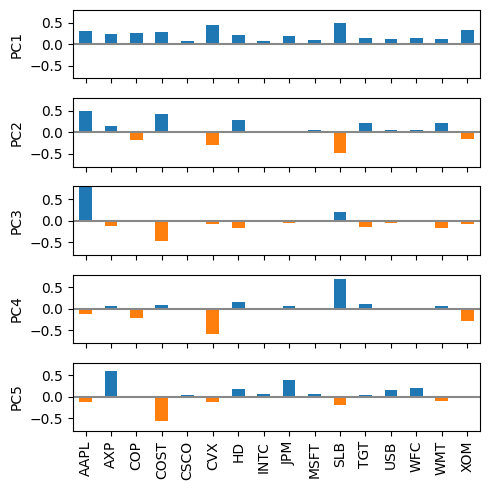

In [45]:
maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()

f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)

for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

In [49]:
import prince
from adjustText import adjust_text

housetasks = pd.read_csv("data/housetasks.csv", index_col=0)
housetasks


,Wife,Alternating,Husband,Jointly
Task,,,,
Laundry,156,14,2,4
Main_meal,124,20,5,4
Dinner,77,11,7,13
Breakfast,82,36,15,7
Tidying,53,11,1,57
Dishes,32,24,4,53
Shopping,33,23,9,55
Official,12,46,23,15
Driving,10,51,75,3


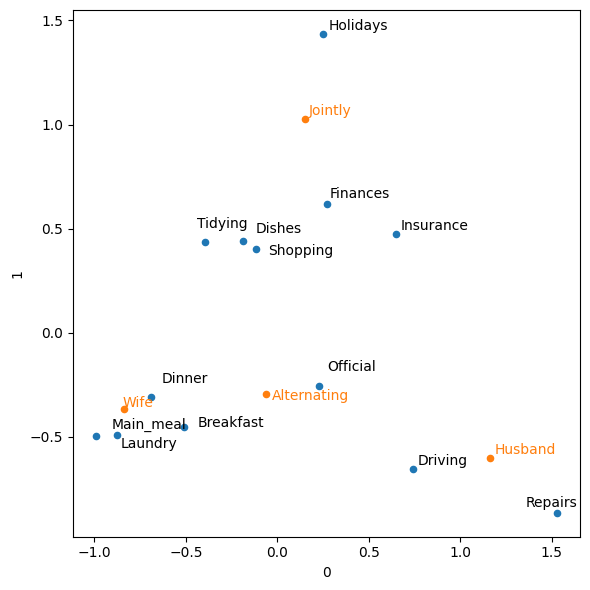

In [60]:
ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(6,6))
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c='C1')
texts = []
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color='C1'))
adjust_text(texts, only_move={'points':'y', 'texts':'y'}) 
plt.tight_layout()
plt.show()

<Axes: xlabel='0', ylabel='1'>